# Balance Hídrico MILPÍN — Visualización del Motor FAO-56
## `backend/core/balance_hidrico.py`

Exploración visual del modelo agronómico: ETo Penman-Monteith, coeficientes de cultivo (Kc), balance hídrico diario y costo de bombeo.

**Contexto geográfico:** Valle del Yaqui, Sonora, México — Módulo 3 DR-041  
**Referencia:** Allen et al. (1998), FAO Irrigation and Drainage Paper 56.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


In [10]:
import sys, os
sys.path.insert(0, os.path.abspath("../../backend"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from datetime import date, timedelta

from core.balance_hidrico import (
    calcular_eto_penman_monteith,
    calcular_eto_hargreaves,
    obtener_kc,
    KC_TABLE,
    calcular_balance_hidrico,
    calcular_costo_riego,
    propagar_balance_hidrico,
)

# Estilo global
plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657", "#79c0ff"]
print("✓ Módulo balance_hidrico cargado correctamente")

✓ Módulo balance_hidrico cargado correctamente


---
## 1. ETo Penman-Monteith — Ciclo Anual (Valle del Yaqui)

Se calcula ETo día a día para el año completo usando condiciones climáticas sintéticas representativas del Valle del Yaqui: veranos calurosos y secos (julio-agosto), inviernos templados y húmedos.

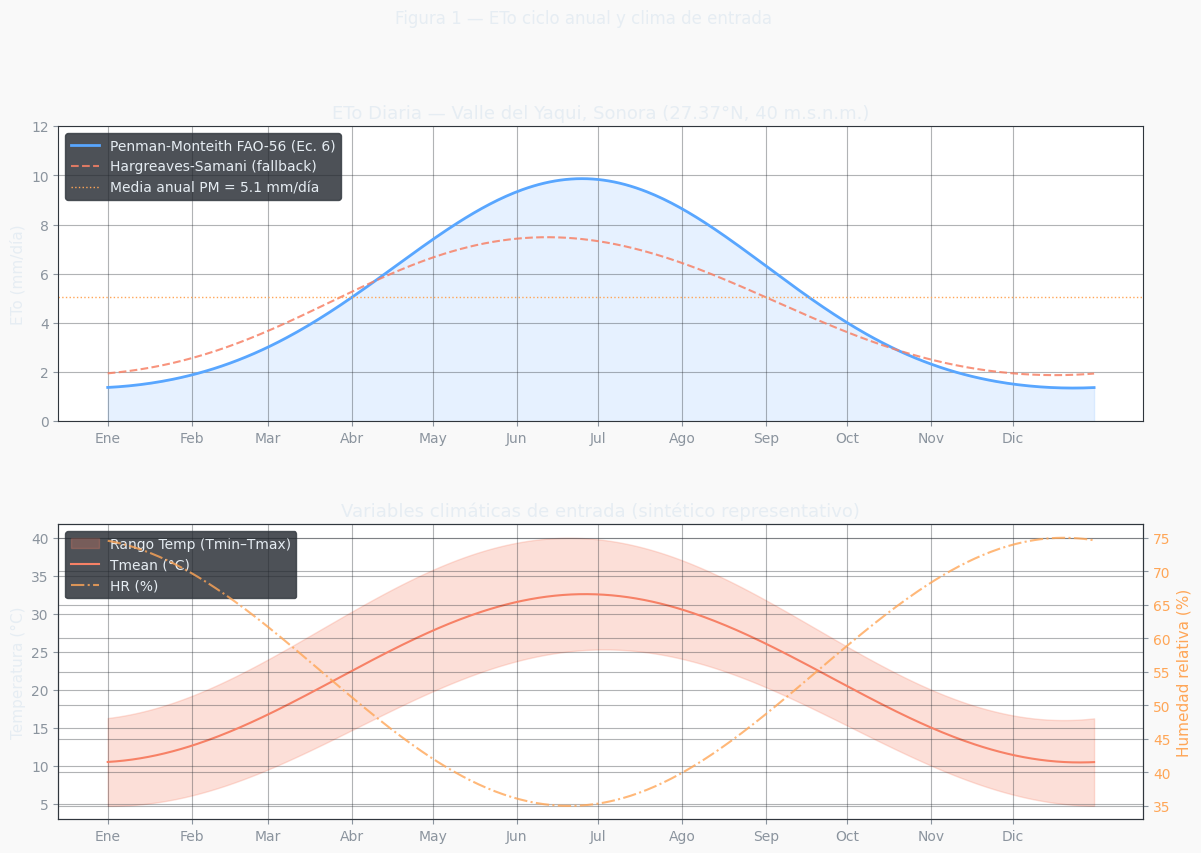

ETo anual acumulada (PM):  1850 mm/año
ETo anual acumulada (HG):  1657 mm/año
Diferencia media PM-HG:    +0.53 mm/día


In [11]:
dias = np.arange(1, 366)

# Clima sintético Valle del Yaqui (ciclo anual típico)
tmax = 28 + 12 * np.sin(2 * np.pi * (dias - 80) / 365)   # 16°C ene → 40°C jul
tmin = tmax - 13 - 3 * np.sin(2 * np.pi * (dias - 30) / 365)
hr   = 55 - 20 * np.sin(2 * np.pi * (dias - 80) / 365)   # 75% ene → 35% jul
hr   = np.clip(hr, 20, 85)
viento = 2.5 + 1.2 * np.sin(2 * np.pi * (dias - 100) / 365)
radiacion = 18 + 9 * np.sin(2 * np.pi * (dias - 80) / 365)  # MJ/m²/día

eto_pm = np.array([
    calcular_eto_penman_monteith(tmax[i], tmin[i], hr[i], viento[i], radiacion[i], dia_del_ano=int(dias[i]))
    for i in range(len(dias))
])
eto_hg = np.array([
    calcular_eto_hargreaves(tmax[i], tmin[i], dia_del_ano=int(dias[i]))
    for i in range(len(dias))
])

meses_labels = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
meses_ticks  = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"hspace": 0.35})

# Panel superior: ETo anual (PM + Hargreaves)
ax = axes[0]
ax.fill_between(dias, eto_pm, alpha=0.15, color=PALETTE[0])
ax.plot(dias, eto_pm, color=PALETTE[0], lw=2, label="Penman-Monteith FAO-56 (Ec. 6)")
ax.plot(dias, eto_hg, color=PALETTE[2], lw=1.5, ls="--", alpha=0.85, label="Hargreaves-Samani (fallback)")
ax.axhline(eto_pm.mean(), color="#ffa657", lw=1, ls=":", label=f"Media anual PM = {eto_pm.mean():.1f} mm/día")
ax.set_xticks(meses_ticks); ax.set_xticklabels(meses_labels)
ax.set_ylabel("ETo (mm/día)"); ax.set_title("ETo Diaria — Valle del Yaqui, Sonora (27.37°N, 40 m.s.n.m.)")
ax.legend(loc="upper left"); ax.grid(True, axis="y")
ax.set_ylim(0, 12)

# Panel inferior: temperatura + HR como contexto
ax2 = axes[1]
ax2.fill_between(dias, tmin, tmax, alpha=0.25, color=PALETTE[2], label="Rango Temp (Tmin–Tmax)")
ax2.plot(dias, (tmax+tmin)/2, color=PALETTE[2], lw=1.5, label="Tmean (°C)")
ax2_r = ax2.twinx()
ax2_r.plot(dias, hr, color=PALETTE[4], lw=1.5, ls="-.", alpha=0.8, label="HR (%)")
ax2_r.set_ylabel("Humedad relativa (%)", color=PALETTE[4])
ax2_r.tick_params(axis="y", labelcolor=PALETTE[4])
ax2.set_xticks(meses_ticks); ax2.set_xticklabels(meses_labels)
ax2.set_ylabel("Temperatura (°C)"); ax2.set_title("Variables climáticas de entrada (sintético representativo)")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax2.grid(True, axis="y")

plt.suptitle("Figura 1 — ETo ciclo anual y clima de entrada", fontsize=12, y=1.01)
plt.savefig("fig1_eto_anual.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"ETo anual acumulada (PM):  {eto_pm.sum():.0f} mm/año")
print(f"ETo anual acumulada (HG):  {eto_hg.sum():.0f} mm/año")
print(f"Diferencia media PM-HG:    {(eto_pm - eto_hg).mean():+.2f} mm/día")

---
## 2. Penman-Monteith vs Hargreaves — Concordancia y Sesgo

Hargreaves solo necesita Tmax y Tmin (útil cuando faltan datos de viento, HR y radiación). Esta sección cuantifica cuánto diverge del método completo PM, y en qué estación del año el sesgo es mayor.

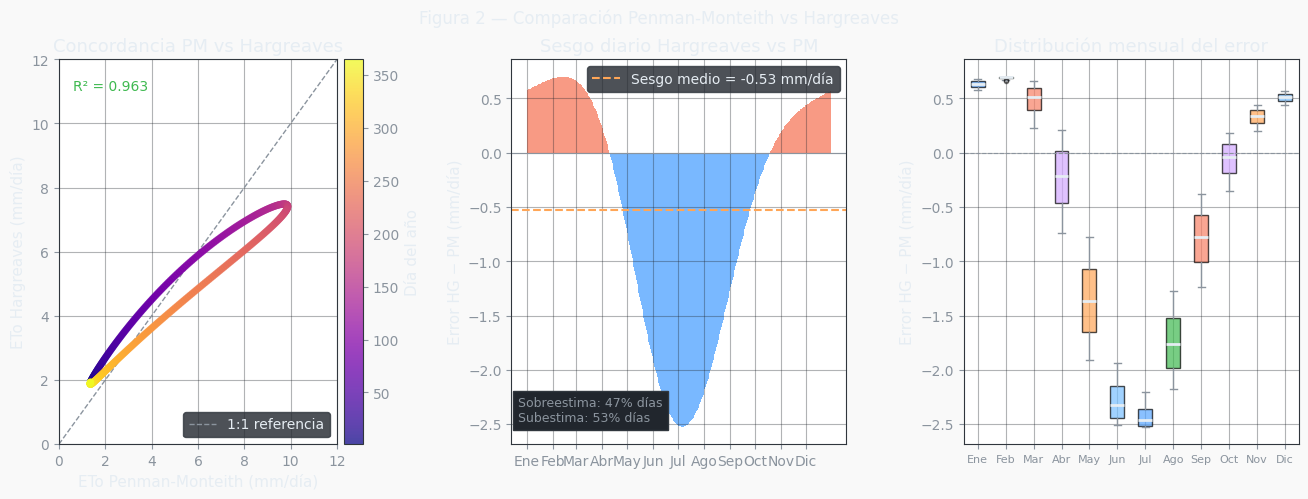

RMSE Hargreaves: 1.250 mm/día
MAE  Hargreaves: 0.978 mm/día


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"wspace": 0.35})

# --- Scatter PM vs HG ---
ax = axes[0]
scatter = ax.scatter(eto_pm, eto_hg, c=dias, cmap="plasma", s=18, alpha=0.75, zorder=3)
lim = (0, 12)
ax.plot(lim, lim, color="#8b949e", lw=1, ls="--", label="1:1 referencia")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("ETo Penman-Monteith (mm/día)")
ax.set_ylabel("ETo Hargreaves (mm/día)")
ax.set_title("Concordancia PM vs Hargreaves")
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Día del año", color="#e6edf3"); cbar.ax.yaxis.set_tick_params(color="#8b949e")
r2 = np.corrcoef(eto_pm, eto_hg)[0,1]**2
ax.text(0.05, 0.92, f"R² = {r2:.3f}", transform=ax.transAxes, fontsize=10, color=PALETTE[1])
ax.legend(); ax.grid(True)

# --- Error diario a lo largo del año ---
ax2 = axes[1]
error = eto_hg - eto_pm
colores_error = [PALETTE[2] if e > 0 else PALETTE[0] for e in error]
ax2.bar(dias, error, color=colores_error, width=1, alpha=0.8)
ax2.axhline(0, color="#8b949e", lw=0.8)
ax2.axhline(error.mean(), color=PALETTE[4], lw=1.5, ls="--",
            label=f"Sesgo medio = {error.mean():+.2f} mm/día")
ax2.set_xticks(meses_ticks); ax2.set_xticklabels(meses_labels)
ax2.set_ylabel("Error HG − PM (mm/día)")
ax2.set_title("Sesgo diario Hargreaves vs PM")
ax2.legend(); ax2.grid(True, axis="y")
sobreestima_pct = (error > 0).mean() * 100
ax2.text(0.02, 0.06,
         f"Sobreestima: {sobreestima_pct:.0f}% días\nSubestima: {100-sobreestima_pct:.0f}% días",
         transform=ax2.transAxes, fontsize=9, color="#8b949e",
         bbox=dict(facecolor="#21262d", edgecolor="#30363d", pad=4))

# --- Error absoluto mensual (boxplot) ---
ax3 = axes[2]
meses_num = pd.Series(dias).apply(
    lambda d: pd.Timestamp(2024, 1, 1) + pd.Timedelta(days=int(d)-1)
).dt.month
error_por_mes = [error[meses_num == m] for m in range(1, 13)]
bp = ax3.boxplot(error_por_mes, patch_artist=True, medianprops=dict(color="#e6edf3", lw=2),
                 whiskerprops=dict(color="#8b949e"), capprops=dict(color="#8b949e"),
                 flierprops=dict(marker=".", color="#8b949e", alpha=0.5))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(PALETTE[i % len(PALETTE)])
    patch.set_alpha(0.7)
ax3.axhline(0, color="#8b949e", lw=0.8, ls="--")
ax3.set_xticklabels(meses_labels, fontsize=8)
ax3.set_ylabel("Error HG − PM (mm/día)")
ax3.set_title("Distribución mensual del error")
ax3.grid(True, axis="y")

plt.suptitle("Figura 2 — Comparación Penman-Monteith vs Hargreaves", fontsize=12)
plt.savefig("fig2_pm_vs_hargreaves.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"RMSE Hargreaves: {np.sqrt(np.mean(error**2)):.3f} mm/día")
print(f"MAE  Hargreaves: {np.mean(np.abs(error)):.3f} mm/día")

---
## 3. Análisis de Sensibilidad de ETo (Penman-Monteith)

¿Qué variable climática tiene más influencia sobre ETo? Se varía una variable a la vez manteniendo las demás fijas en valores típicos de verano (día 200: ~19 julio, pico de demanda hídrica en el Valle del Yaqui).

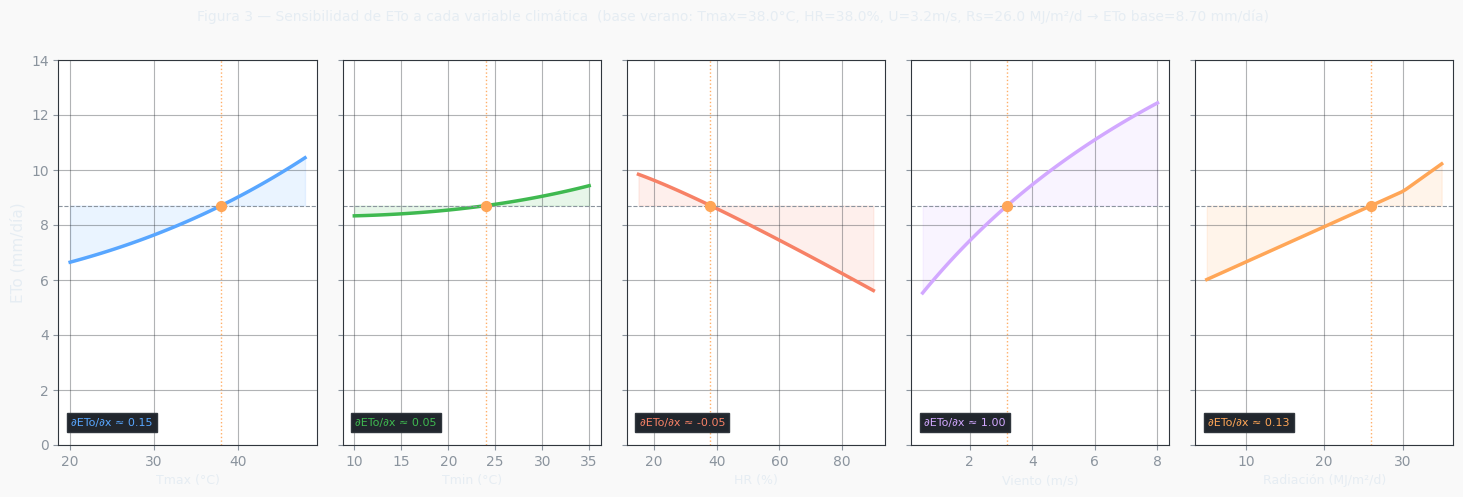

In [13]:
# Valores base verano (día 200 ≈ 19 jul)
BASE = dict(tmax=38.0, tmin=24.0, hr=38.0, viento=3.2, rad=26.0, dia=200)

rangos = {
    "Tmax (°C)":       np.linspace(20, 48, 60),
    "Tmin (°C)":       np.linspace(10, 35, 60),
    "HR (%)":          np.linspace(15, 90, 60),
    "Viento (m/s)":    np.linspace(0.5, 8, 60),
    "Radiación (MJ/m²/d)": np.linspace(5, 35, 60),
}

def eto_variando(param, valores):
    result = []
    for v in valores:
        args = dict(BASE)
        if param == "Tmax (°C)":
            result.append(calcular_eto_penman_monteith(v, args["tmin"], args["hr"], args["viento"], args["rad"], dia_del_ano=args["dia"]))
        elif param == "Tmin (°C)":
            result.append(calcular_eto_penman_monteith(args["tmax"], v, args["hr"], args["viento"], args["rad"], dia_del_ano=args["dia"]))
        elif param == "HR (%)":
            result.append(calcular_eto_penman_monteith(args["tmax"], args["tmin"], v, args["viento"], args["rad"], dia_del_ano=args["dia"]))
        elif param == "Viento (m/s)":
            result.append(calcular_eto_penman_monteith(args["tmax"], args["tmin"], args["hr"], v, args["rad"], dia_del_ano=args["dia"]))
        elif param == "Radiación (MJ/m²/d)":
            result.append(calcular_eto_penman_monteith(args["tmax"], args["tmin"], args["hr"], args["viento"], v, dia_del_ano=args["dia"]))
    return np.array(result)

eto_base = calcular_eto_penman_monteith(
    BASE["tmax"], BASE["tmin"], BASE["hr"], BASE["viento"], BASE["rad"], dia_del_ano=BASE["dia"]
)

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True, gridspec_kw={"wspace": 0.1})

for idx, (param, rango) in enumerate(rangos.items()):
    eto_v = eto_variando(param, rango)
    ax = axes[idx]
    ax.plot(rango, eto_v, color=PALETTE[idx], lw=2.5)
    ax.fill_between(rango, eto_v, eto_base, alpha=0.12, color=PALETTE[idx])
    ax.axhline(eto_base, color="#8b949e", lw=0.8, ls="--")

    # Marcar el valor base
    if param == "Tmax (°C)":      bv = BASE["tmax"]
    elif param == "Tmin (°C)":    bv = BASE["tmin"]
    elif param == "HR (%)":       bv = BASE["hr"]
    elif param == "Viento (m/s)": bv = BASE["viento"]
    else:                          bv = BASE["rad"]

    ax.axvline(bv, color="#ffa657", lw=1, ls=":", alpha=0.9)
    ax.scatter([bv], [eto_base], color="#ffa657", s=50, zorder=5)
    ax.set_xlabel(param, fontsize=9)
    ax.grid(True, axis="y")

    # Sensibilidad: pendiente normalizada en el punto base
    i_base = np.argmin(np.abs(rango - bv))
    di = max(1, int(len(rango) * 0.05))
    slope = (eto_v[min(i_base+di, len(rango)-1)] - eto_v[max(i_base-di, 0)]) / (rango[min(i_base+di, len(rango)-1)] - rango[max(i_base-di, 0)])
    ax.text(0.05, 0.05, f"∂ETo/∂x ≈ {slope:.2f}", transform=ax.transAxes,
            fontsize=8, color=PALETTE[idx],
            bbox=dict(facecolor="#21262d", edgecolor="#30363d", pad=3))

axes[0].set_ylabel("ETo (mm/día)")
axes[0].set_ylim(0, 14)
plt.suptitle(
    f"Figura 3 — Sensibilidad de ETo a cada variable climática  "
    f"(base verano: Tmax={BASE['tmax']}°C, HR={BASE['hr']}%, U={BASE['viento']}m/s, "
    f"Rs={BASE['rad']} MJ/m²/d → ETo base={eto_base:.2f} mm/día)",
    fontsize=10
)
plt.savefig("fig3_sensibilidad_eto.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 4. Curvas Kc FAO-56 — Los 5 Cultivos del DR-041

Coeficientes de cultivo (Kc) a lo largo del ciclo fenológico completo para los 5 cultivos oficiales de MILPÍN: Maíz, Frijol, Algodón, Uva y Chile. La lógica de interpolación lineal en etapas de desarrollo y final está implementada en `obtener_kc()`.

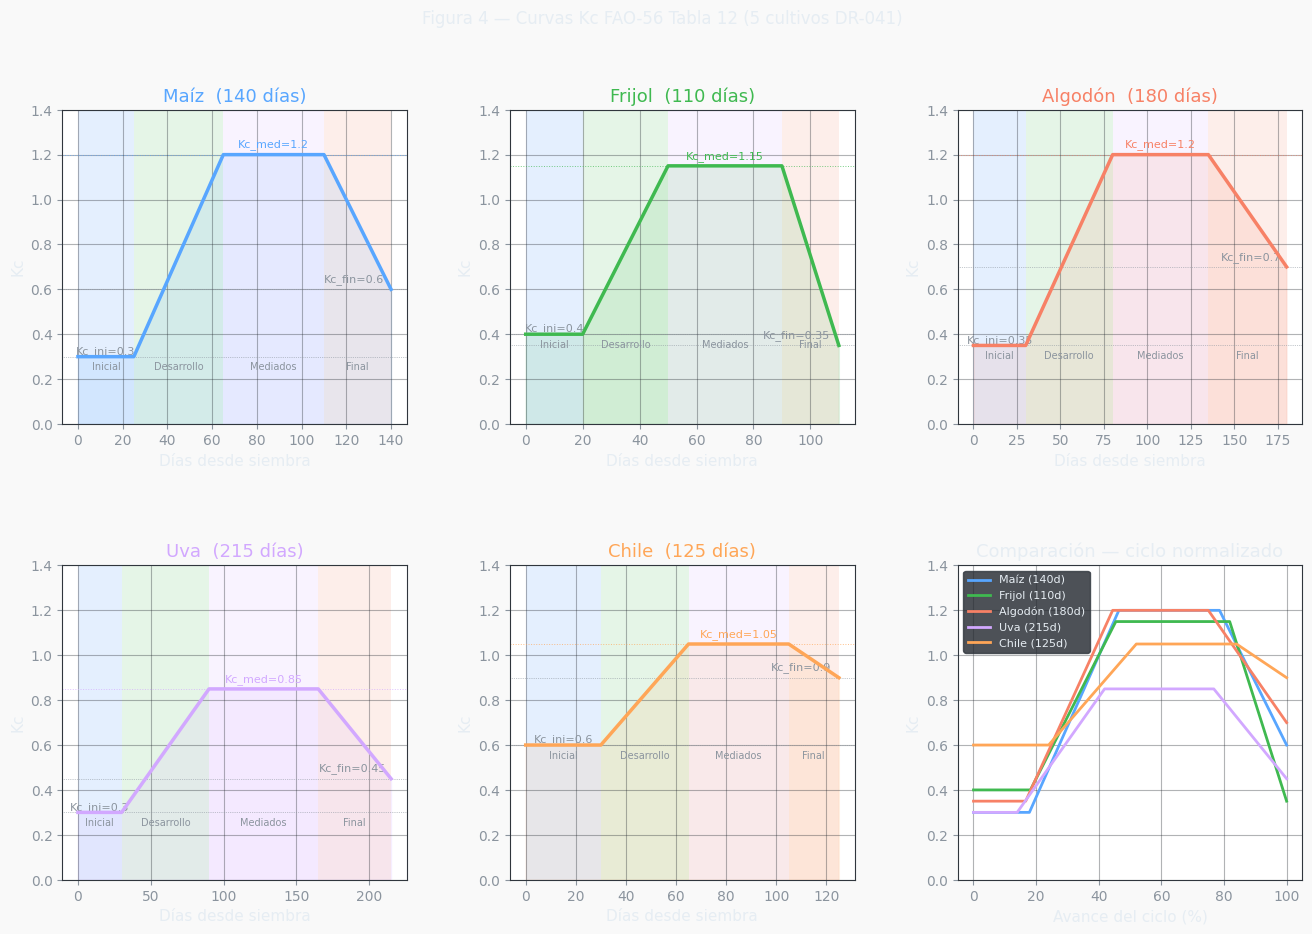


Cultivo     Kc_ini  Kc_med  Kc_fin   Ciclo
---------------------------------------------
Maíz          0.30    1.20    0.60    140d
Frijol        0.40    1.15    0.35    110d
Algodón       0.35    1.20    0.70    180d
Uva           0.30    0.85    0.45    215d
Chile         0.60    1.05    0.90    125d


In [14]:
cultivos = list(KC_TABLE.keys())
nombres_display = {"maiz": "Maíz", "frijol": "Frijol", "algodon": "Algodón",
                   "uva": "Uva", "chile": "Chile"}
etapas_nombres = ["Inicial", "Desarrollo", "Mediados", "Final"]
colores_etapa  = ["#388bfd22", "#3fb95022", "#d2a8ff22", "#f7816622"]

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
axes_kc = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(5)]
ax_comp  = fig.add_subplot(gs[1, 2])

for idx, cultivo in enumerate(cultivos):
    info   = KC_TABLE[cultivo]
    d_ini, d_des, d_med, d_fin = info["duracion_etapas"]
    kc_ini, kc_med, kc_fin     = info["kc"]
    ciclo  = d_ini + d_des + d_med + d_fin
    dias_c = np.arange(0, ciclo + 1)
    kc_v   = np.array([obtener_kc(cultivo, d) for d in dias_c])

    ax = axes_kc[idx]
    # Fondos de etapa
    limites = [0, d_ini, d_ini+d_des, d_ini+d_des+d_med, ciclo]
    for e in range(4):
        ax.axvspan(limites[e], limites[e+1], facecolor=colores_etapa[e], lw=0)
        ax.text((limites[e]+limites[e+1])/2, kc_ini - 0.06,
                etapas_nombres[e], ha="center", fontsize=7, color="#8b949e")

    ax.plot(dias_c, kc_v, color=PALETTE[idx], lw=2.5, zorder=4)
    ax.fill_between(dias_c, kc_v, alpha=0.12, color=PALETTE[idx])

    # Líneas de referencia Kc
    ax.axhline(kc_med, color=PALETTE[idx], lw=0.7, ls=":", alpha=0.7)
    ax.axhline(kc_ini, color="#8b949e", lw=0.5, ls=":")
    ax.axhline(kc_fin, color="#8b949e", lw=0.5, ls=":")

    # Anotaciones
    ax.annotate(f"Kc_ini={kc_ini}", xy=(d_ini/2, kc_ini), fontsize=8, color="#8b949e",
                ha="center", va="bottom")
    ax.annotate(f"Kc_med={kc_med}", xy=(d_ini+d_des+d_med/2, kc_med+0.02),
                fontsize=8, color=PALETTE[idx], ha="center", va="bottom")
    ax.annotate(f"Kc_fin={kc_fin}", xy=(ciclo-3, kc_fin+0.02),
                fontsize=8, color="#8b949e", ha="right", va="bottom")

    ax.set_title(f"{nombres_display[cultivo]}  ({ciclo} días)", color=PALETTE[idx])
    ax.set_xlabel("Días desde siembra"); ax.set_ylabel("Kc")
    ax.set_ylim(0, 1.4); ax.grid(True, axis="y")

# Panel comparativo: todos los cultivos en una gráfica
for idx, cultivo in enumerate(cultivos):
    info  = KC_TABLE[cultivo]
    ciclo = sum(info["duracion_etapas"])
    dias_c = np.arange(0, ciclo + 1)
    kc_v   = np.array([obtener_kc(cultivo, d) for d in dias_c])
    pct    = dias_c / ciclo * 100
    ax_comp.plot(pct, kc_v, color=PALETTE[idx], lw=2,
                 label=f"{nombres_display[cultivo]} ({ciclo}d)")

ax_comp.set_xlabel("Avance del ciclo (%)")
ax_comp.set_ylabel("Kc")
ax_comp.set_title("Comparación — ciclo normalizado")
ax_comp.legend(fontsize=8); ax_comp.grid(True)
ax_comp.set_ylim(0, 1.4)

plt.suptitle("Figura 4 — Curvas Kc FAO-56 Tabla 12 (5 cultivos DR-041)", fontsize=12)
plt.savefig("fig4_curvas_kc.png", dpi=130, bbox_inches="tight")
plt.show()

# Tabla resumen
print(f"\n{'Cultivo':<10} {'Kc_ini':>7} {'Kc_med':>7} {'Kc_fin':>7} {'Ciclo':>7}")
print("-" * 45)
for c in cultivos:
    info = KC_TABLE[c]
    ki, km, kf = info["kc"]
    ciclo = sum(info["duracion_etapas"])
    print(f"{nombres_display[c]:<10} {ki:>7.2f} {km:>7.2f} {kf:>7.2f} {ciclo:>6}d")

---
## 5. Balance Hídrico Diario Simulado — `calcular_balance_hidrico()`

Simulación de 60 días de balance hídrico para una parcela de maíz en etapa de mediados de temporada (Kc_med = 1.20). Se incluyen dos eventos de lluvia moderada y se visualiza cuándo el sistema recomienda regar (humedad < umbral 50% ADT).

C:\Users\madri\AppData\Local\Temp\ipykernel_20516\13247345.py:98: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  plt.savefig("fig5_balance_hidrico.png", dpi=130, bbox_inches="tight")
c:\Users\madri\Downloads\pp26(Omar)\milpin_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


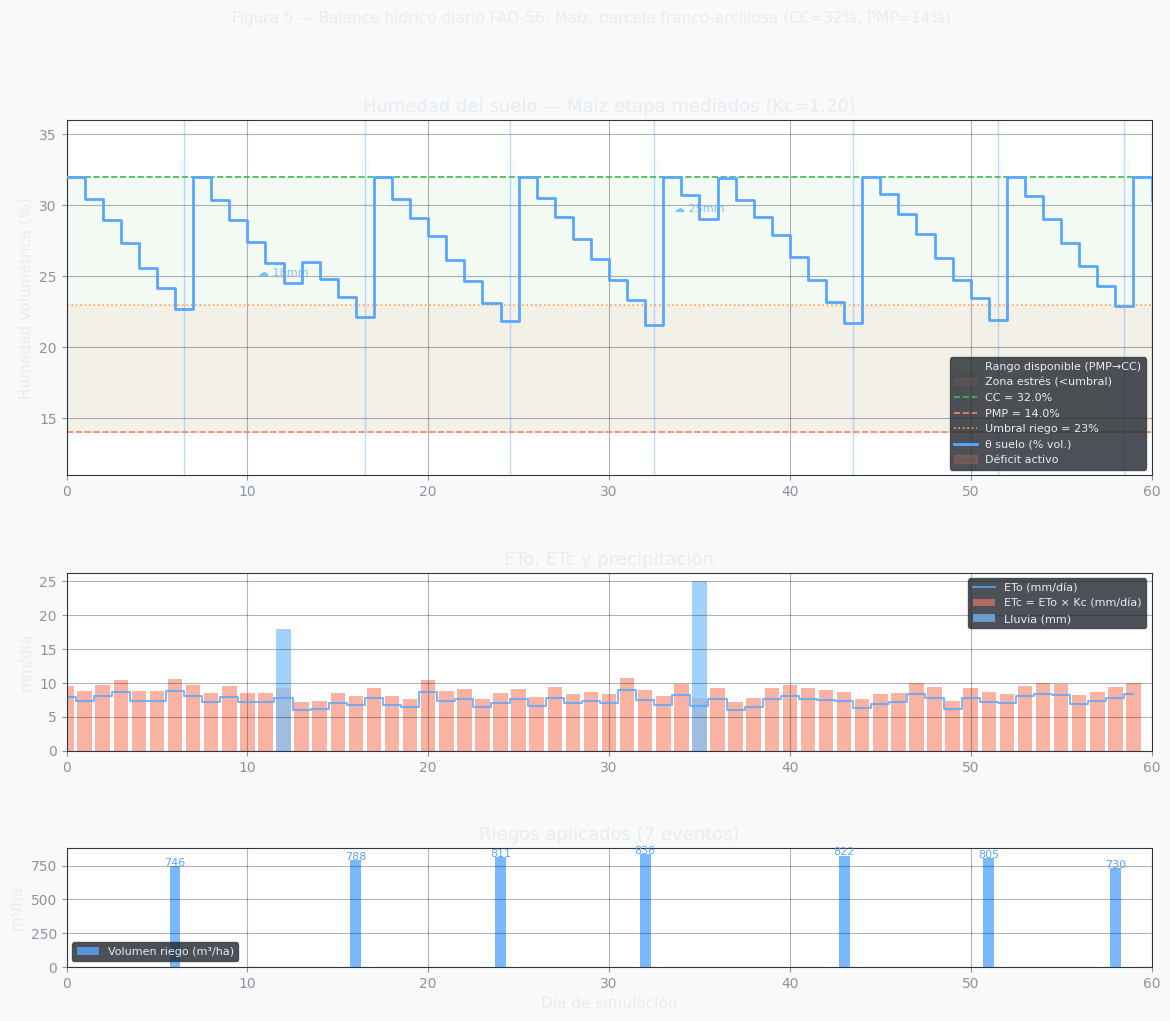


Resumen simulación (60 días):
  Riegos aplicados:       7
  Volumen total:          5537 m³/ha
  ETc acumulada:          531 mm
  Lluvia acumulada:       43 mm
  Humedad final:          30.3%


In [15]:
np.random.seed(42)

# Parámetros de suelo (franco-arcilloso típico Valle del Yaqui)
CC    = 32.0   # capacidad de campo (%)
PMP   = 14.0   # punto marchitez permanente (%)
PROF  = 0.6    # profundidad radicular maíz (m)
KC    = 1.20   # Kc_med maíz
EFF   = 0.75   # eficiencia de riego

# Umbral de riego (50% ADT — criterio FAO)
umbral = PMP + 0.50 * (CC - PMP)   # = 23%

N = 60  # días de simulación

# Clima diario: verano tardío en Valle del Yaqui (eto variable + 2 lluvias)
eto_sim  = 7.5 + np.random.randn(N) * 0.8
lluvia   = np.zeros(N)
lluvia[12] = 18.0   # lluvia evento 1: día 13
lluvia[35] = 25.0   # lluvia evento 2: día 36

# Simular día a día; aplicar riego cuando humedad < umbral
humedad   = np.zeros(N + 1)
humedad[0] = CC   # parcela inicia a CC (primer riego ya aplicado)
riegos       = []
volumen_riegos = []

for t in range(N):
    etc = eto_sim[t] * KC
    balance = calcular_balance_hidrico(
        etc_mm=etc,
        precipitacion_mm=lluvia[t],
        humedad_actual_pct=humedad[t],
        capacidad_campo_pct=CC,
        punto_marchitez_pct=PMP,
        profundidad_raiz_m=PROF,
    )
    humedad[t + 1] = balance["humedad_resultante_pct"]

    if balance["requiere_riego"] and humedad[t] < umbral:
        # Aplicar riego: reponer hasta CC
        lamina_bruta = balance["lamina_bruta_mm"]
        vol = lamina_bruta * 10  # m³/ha
        humedad[t + 1] = CC      # riego lleva a CC
        riegos.append(t)
        volumen_riegos.append(vol)

dias_sim  = np.arange(N + 1)
eto_plot  = np.append(eto_sim, eto_sim[-1])
etc_plot  = eto_plot * KC

fig, axes = plt.subplots(3, 1, figsize=(14, 11), gridspec_kw={"hspace": 0.45, "height_ratios": [3, 1.5, 1]})

# --- Panel 1: Humedad del suelo ---
ax1 = axes[0]
ax1.fill_between(dias_sim, PMP, CC, alpha=0.06, color=PALETTE[1], label="Rango disponible (PMP→CC)")
ax1.fill_between(dias_sim, PMP, umbral, alpha=0.08, color=PALETTE[2], label="Zona estrés (<umbral)")
ax1.axhline(CC,     color=PALETTE[1], lw=1.2, ls="--", label=f"CC = {CC}%")
ax1.axhline(PMP,    color=PALETTE[2], lw=1.2, ls="--", label=f"PMP = {PMP}%")
ax1.axhline(umbral, color=PALETTE[4], lw=1.2, ls=":",  label=f"Umbral riego = {umbral:.0f}%")
ax1.step(dias_sim, humedad, color=PALETTE[0], lw=2, where="post", label="θ suelo (% vol.)", zorder=4)
ax1.fill_between(dias_sim, humedad, umbral, where=(humedad < umbral),
                 step="post", alpha=0.2, color=PALETTE[2], label="Déficit activo")

# Marcar riegos
for d in riegos:
    ax1.axvline(d + 0.5, color=PALETTE[0], lw=1, alpha=0.4, ls="-")
    ax1.annotate("💧", xy=(d + 0.5, CC + 0.3), ha="center", fontsize=11)

# Marcar lluvias
for t in range(N):
    if lluvia[t] > 0:
        ax1.annotate(f"☁ {lluvia[t]:.0f}mm", xy=(t, humedad[t]+0.5),
                     fontsize=8, color="#79c0ff", ha="center")

ax1.set_xlim(0, N); ax1.set_ylim(PMP - 3, CC + 4)
ax1.set_ylabel("Humedad volumétrica (%)"); ax1.set_title("Humedad del suelo — Maíz etapa mediados (Kc=1.20)")
ax1.legend(loc="lower right", fontsize=8); ax1.grid(True, axis="y")

# --- Panel 2: ETo y ETc ---
ax2 = axes[1]
ax2.bar(np.arange(N), etc_plot[:N], color=PALETTE[2], alpha=0.6, label="ETc = ETo × Kc (mm/día)", width=0.8)
ax2.step(np.arange(N), eto_plot[:N], color=PALETTE[0], lw=1.5, where="mid", label="ETo (mm/día)", alpha=0.8)
ax2.bar(np.arange(N), lluvia, color=PALETTE[5], alpha=0.7, label="Lluvia (mm)", width=0.8, bottom=0)
ax2.set_xlim(0, N); ax2.set_ylabel("mm/día"); ax2.set_title("ETo, ETc y precipitación")
ax2.legend(fontsize=8); ax2.grid(True, axis="y")

# --- Panel 3: Volúmenes de riego ---
ax3 = axes[2]
if riegos:
    ax3.bar(riegos, volumen_riegos, color=PALETTE[0], alpha=0.8, width=0.6, label="Volumen riego (m³/ha)")
    for d, v in zip(riegos, volumen_riegos):
        ax3.text(d, v + 5, f"{v:.0f}", ha="center", fontsize=8, color=PALETTE[0])
ax3.set_xlim(0, N); ax3.set_ylabel("m³/ha"); ax3.set_xlabel("Día de simulación")
ax3.set_title(f"Riegos aplicados ({len(riegos)} eventos)")
ax3.legend(fontsize=8); ax3.grid(True, axis="y")

plt.suptitle("Figura 5 — Balance hídrico diario FAO-56: Maíz, parcela franco-arcillosa (CC=32%, PMP=14%)", fontsize=11)
plt.savefig("fig5_balance_hidrico.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\nResumen simulación (60 días):")
print(f"  Riegos aplicados:       {len(riegos)}")
print(f"  Volumen total:          {sum(volumen_riegos):.0f} m³/ha")
print(f"  ETc acumulada:          {(eto_sim * KC).sum():.0f} mm")
print(f"  Lluvia acumulada:       {lluvia.sum():.0f} mm")
print(f"  Humedad final:          {humedad[-1]:.1f}%")

---
## 6. `propagar_balance_hidrico()` — Evolución desde el Último Riego

Esta función (resuelta 2026-05-06) reemplaza la simplificación `(CC+PMP)/2` con una propagación física día a día. Aquí se visualiza cómo la humedad estimada depende de los días transcurridos desde el último riego, y la sensibilidad al nivel de ETo promedio.

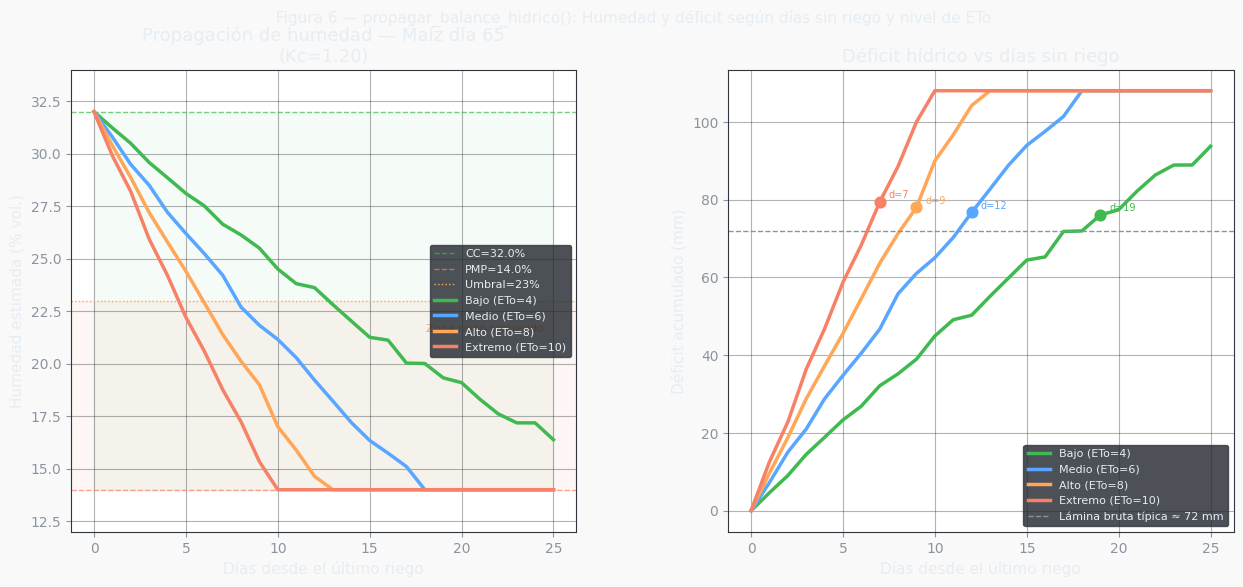

Método antiguo (CC+PMP)/2 = 23.0%  (constante, sin importar días)
Propagación día 15 @ ETo=8: 14.0%
  → Error del método viejo en día 15: +9.0%


In [16]:
from datetime import date, timedelta

# Configuración base
CC_p, PMP_p, PROF_p = 32.0, 14.0, 0.6
CULTIVO   = "maiz"
DIA_SIEM  = 65   # días desde siembra en fecha_ref (etapa mediados)
FECHA_REF = date(2026, 5, 18)

escenarios_eto = {
    "Bajo (ETo=4)":   4.0,
    "Medio (ETo=6)":  6.0,
    "Alto (ETo=8)":   8.0,
    "Extremo (ETo=10)": 10.0,
}
colores_esc = [PALETTE[1], PALETTE[0], PALETTE[4], PALETTE[2]]

max_dias_atras = 25  # máximo de días desde el último riego que se evalúa
dias_atras_rango = range(0, max_dias_atras + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"wspace": 0.3})

# --- Panel izquierdo: humedad vs días desde último riego por escenario ETo ---
ax = axes[0]
ax.fill_between(dias_atras_rango, PMP_p, CC_p, alpha=0.05, color=PALETTE[1])
ax.axhline(CC_p,    color=PALETTE[1], lw=1, ls="--", label=f"CC={CC_p}%", alpha=0.7)
ax.axhline(PMP_p,   color=PALETTE[2], lw=1, ls="--", label=f"PMP={PMP_p}%", alpha=0.7)
umbral_p = PMP_p + 0.5 * (CC_p - PMP_p)
ax.axhline(umbral_p, color=PALETTE[4], lw=1, ls=":", label=f"Umbral={umbral_p:.0f}%")

resultados = {}
for (label, eto_val), color in zip(escenarios_eto.items(), colores_esc):
    humedades = []
    deficits  = []
    for d in dias_atras_rango:
        fecha_riego = FECHA_REF - timedelta(days=d)
        # Construir registros climáticos sintéticos para el periodo
        clima_recs = [
            {"fecha": fecha_riego + timedelta(days=k+1),
             "et0": eto_val + np.random.randn() * 0.3,
             "lluvia": 0.0}
            for k in range(d)
        ]
        res = propagar_balance_hidrico(
            fecha_ultimo_riego=fecha_riego,
            fecha_ref=FECHA_REF,
            cc_pct=CC_p, pmp_pct=PMP_p, prof_raiz_m=PROF_p,
            cultivo_nombre=CULTIVO,
            dias_siembra_ref=DIA_SIEM,
            clima_records=clima_recs,
        )
        humedades.append(res["humedad_actual_pct"])
        deficits.append(res["deficit_acumulado_mm"])
    resultados[label] = {"humedad": humedades, "deficit": deficits}
    ax.plot(list(dias_atras_rango), humedades, color=color, lw=2.5, label=label)

# Zona donde requiere riego
ax.axhspan(PMP_p, umbral_p, alpha=0.07, color=PALETTE[2])
ax.text(max_dias_atras * 0.98, umbral_p - 1.5, "Zona riego requerido",
        ha="right", fontsize=8, color=PALETTE[4])

ax.set_xlabel("Días desde el último riego")
ax.set_ylabel("Humedad estimada (% vol.)")
ax.set_title(f"Propagación de humedad — Maíz día {DIA_SIEM}\n(Kc={obtener_kc('maiz', DIA_SIEM):.2f})")
ax.legend(fontsize=8); ax.grid(True)
ax.set_ylim(PMP_p - 2, CC_p + 2)

# --- Panel derecho: déficit acumulado (mm) por escenario ---
ax2 = axes[1]
for (label, _), color in zip(escenarios_eto.items(), colores_esc):
    ax2.plot(list(dias_atras_rango), resultados[label]["deficit"],
             color=color, lw=2.5, label=label)

# Línea de referencia: lámina bruta promedio
lamina_prom = (CC_p - umbral_p) * PROF_p * 10 / 0.75
ax2.axhline(lamina_prom, color="#8b949e", lw=1, ls="--",
            label=f"Lámina bruta típica ≈ {lamina_prom:.0f} mm")
ax2.set_xlabel("Días desde el último riego")
ax2.set_ylabel("Déficit acumulado (mm)")
ax2.set_title("Déficit hídrico vs días sin riego")
ax2.legend(fontsize=8); ax2.grid(True)

# Anotar punto de quiebre donde cada escenario supera la lámina bruta
for (label, _), color in zip(escenarios_eto.items(), colores_esc):
    defs = resultados[label]["deficit"]
    for d, def_val in enumerate(defs):
        if def_val >= lamina_prom:
            ax2.scatter([d], [def_val], color=color, s=60, zorder=5)
            ax2.annotate(f"d={d}", xy=(d, def_val), xytext=(d+0.5, def_val+1),
                         fontsize=7, color=color)
            break

plt.suptitle("Figura 6 — propagar_balance_hidrico(): Humedad y déficit según días sin riego y nivel de ETo",
             fontsize=11)
plt.savefig("fig6_propagacion.png", dpi=130, bbox_inches="tight")
plt.show()

# Comparar con método antiguo (CC+PMP)/2
humedad_viejo = (CC_p + PMP_p) / 2
print(f"Método antiguo (CC+PMP)/2 = {humedad_viejo:.1f}%  (constante, sin importar días)")
print(f"Propagación día 15 @ ETo=8: {resultados['Alto (ETo=8)']['humedad'][15]:.1f}%")
print(f"  → Error del método viejo en día 15: {humedad_viejo - resultados['Alto (ETo=8)']['humedad'][15]:+.1f}%")

---
## 7. Costo de Bombeo — `calcular_costo_riego()`

KPI central del proyecto: reducir de 8,000 → 6,000 m³/ha/ciclo (ahorro 25%). Esta sección cuantifica el impacto económico de esa reducción usando la tarifa CFE 9-CU (bombeo a 80 m).

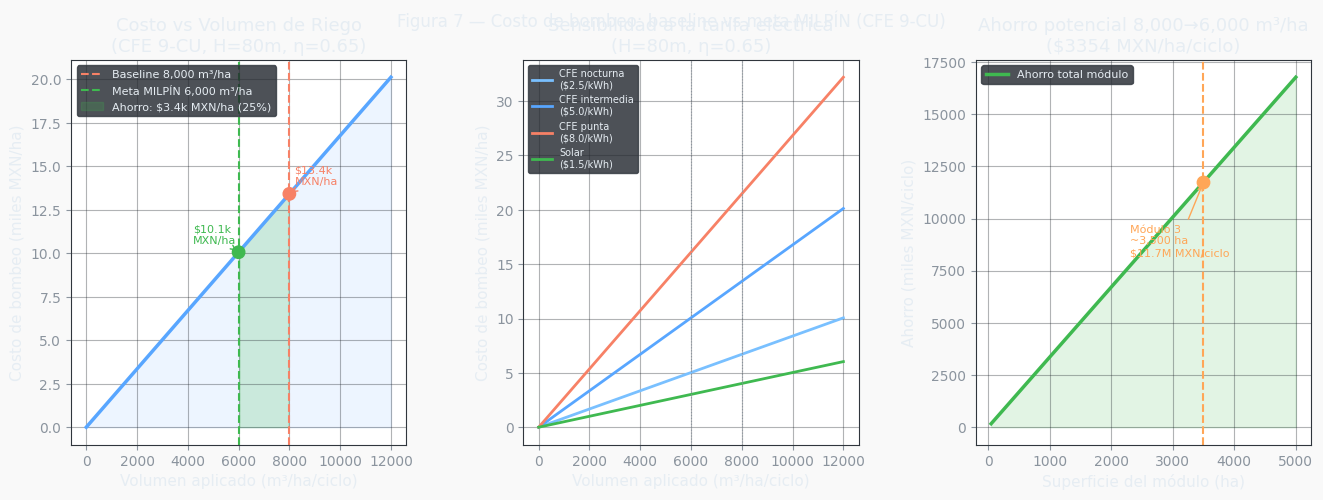


─── KPI Central MILPÍN ───────────────────────────────────
  Consumo baseline:     8,000 m³/ha/ciclo
  Consumo meta:         6,000  m³/ha/ciclo  (−25%)
  Costo baseline:       $13,415 MXN/ha  (2683 kWh)
  Costo meta:           $10,062  MXN/ha  (2012 kWh)
  Ahorro por hectárea:  $3,354 MXN/ha/ciclo  (25.0%)
  Ahorro Módulo 3 (~3,500ha): $11.74M MXN/ciclo


In [17]:
volumenes = np.linspace(0, 12000, 200)  # m³/ha/ciclo

def costo_ciclo(vol_ha, prof=80, eta=0.65, kwh=5.0):
    r = calcular_costo_riego(vol_ha, prof, eta, kwh)
    return r["costo_pesos"], r["energia_kwh"]

costos_pesos = np.array([costo_ciclo(v)[0] for v in volumenes])
energia_kwh  = np.array([costo_ciclo(v)[1] for v in volumenes])

# Puntos de referencia
V_ACTUAL = 8000; V_META = 6000
c_actual, e_actual = costo_ciclo(V_ACTUAL)
c_meta,   e_meta   = costo_ciclo(V_META)
ahorro_pesos = c_actual - c_meta
ahorro_pct   = ahorro_pesos / c_actual * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"wspace": 0.35})

# --- Costo vs volumen ---
ax1 = axes[0]
ax1.plot(volumenes, costos_pesos / 1000, color=PALETTE[0], lw=2.5)
ax1.fill_between(volumenes, costos_pesos / 1000, alpha=0.1, color=PALETTE[0])

# Marcadores baseline y meta
ax1.axvline(V_ACTUAL, color=PALETTE[2], lw=1.5, ls="--", label=f"Baseline {V_ACTUAL:,} m³/ha")
ax1.axvline(V_META,   color=PALETTE[1], lw=1.5, ls="--", label=f"Meta MILPÍN {V_META:,} m³/ha")
ax1.scatter([V_ACTUAL, V_META], [c_actual/1000, c_meta/1000],
            color=[PALETTE[2], PALETTE[1]], s=80, zorder=5)

ax1.annotate(f"${c_actual/1000:.1f}k\nMXN/ha", xy=(V_ACTUAL, c_actual/1000),
             xytext=(V_ACTUAL+200, c_actual/1000 + 0.5),
             fontsize=8, color=PALETTE[2], arrowprops=dict(arrowstyle="->", color=PALETTE[2]))
ax1.annotate(f"${c_meta/1000:.1f}k\nMXN/ha", xy=(V_META, c_meta/1000),
             xytext=(V_META-1800, c_meta/1000 + 0.5),
             fontsize=8, color=PALETTE[1], arrowprops=dict(arrowstyle="->", color=PALETTE[1]))

# Área de ahorro
mask = (volumenes >= V_META) & (volumenes <= V_ACTUAL)
ax1.fill_between(volumenes[mask], costos_pesos[mask]/1000, color=PALETTE[1], alpha=0.2, label=f"Ahorro: ${ahorro_pesos/1000:.1f}k MXN/ha ({ahorro_pct:.0f}%)")

ax1.set_xlabel("Volumen aplicado (m³/ha/ciclo)")
ax1.set_ylabel("Costo de bombeo (miles MXN/ha)")
ax1.set_title("Costo vs Volumen de Riego\n(CFE 9-CU, H=80m, η=0.65)")
ax1.legend(fontsize=8); ax1.grid(True)

# --- Sensibilidad al costo de kWh ---
ax2 = axes[1]
tarifas = {"CFE nocturna\n($2.5/kWh)": 2.5, "CFE intermedia\n($5.0/kWh)": 5.0,
           "CFE punta\n($8.0/kWh)": 8.0, "Solar\n($1.5/kWh)": 1.5}
colores_t = [PALETTE[5], PALETTE[0], PALETTE[2], PALETTE[1]]

for (label, kwh_val), color in zip(tarifas.items(), colores_t):
    costos_t = np.array([costo_ciclo(v, kwh=kwh_val)[0] for v in volumenes])
    ax2.plot(volumenes, costos_t / 1000, color=color, lw=2, label=label)

ax2.axvline(V_ACTUAL, color="#8b949e", lw=0.8, ls=":")
ax2.axvline(V_META,   color="#8b949e", lw=0.8, ls=":")
ax2.set_xlabel("Volumen aplicado (m³/ha/ciclo)")
ax2.set_ylabel("Costo de bombeo (miles MXN/ha)")
ax2.set_title("Sensibilidad a la tarifa eléctrica\n(H=80m, η=0.65)")
ax2.legend(fontsize=7); ax2.grid(True)

# --- Ahorro por hectárea y total del módulo ---
ax3 = axes[2]
has_modulo = np.arange(50, 5001, 50)  # hectáreas del módulo
ahorro_total = has_modulo * ahorro_pesos / 1000  # miles MXN

ax3.fill_between(has_modulo, ahorro_total, alpha=0.15, color=PALETTE[1])
ax3.plot(has_modulo, ahorro_total, color=PALETTE[1], lw=2.5, label="Ahorro total módulo")

# Marcar Módulo 3 (~3,500 ha)
has_mod3 = 3500
ahorro_mod3 = has_mod3 * ahorro_pesos / 1000
ax3.axvline(has_mod3, color=PALETTE[4], lw=1.5, ls="--")
ax3.scatter([has_mod3], [ahorro_mod3], color=PALETTE[4], s=80, zorder=5)
ax3.annotate(f"Módulo 3\n~{has_mod3:,} ha\n${ahorro_mod3/1000:.1f}M MXN/ciclo",
             xy=(has_mod3, ahorro_mod3), xytext=(has_mod3-1200, ahorro_mod3*0.7),
             fontsize=8, color=PALETTE[4], arrowprops=dict(arrowstyle="->", color=PALETTE[4]))

ax3.set_xlabel("Superficie del módulo (ha)")
ax3.set_ylabel("Ahorro (miles MXN/ciclo)")
ax3.set_title(f"Ahorro potencial 8,000→6,000 m³/ha\n(${ahorro_pesos:.0f} MXN/ha/ciclo)")
ax3.legend(fontsize=8); ax3.grid(True)

plt.suptitle("Figura 7 — Costo de bombeo: baseline vs meta MILPÍN (CFE 9-CU)", fontsize=12)
plt.savefig("fig7_costo_riego.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\n─── KPI Central MILPÍN ───────────────────────────────────")
print(f"  Consumo baseline:     {V_ACTUAL:,} m³/ha/ciclo")
print(f"  Consumo meta:         {V_META:,}  m³/ha/ciclo  (−25%)")
print(f"  Costo baseline:       ${c_actual:,.0f} MXN/ha  ({e_actual:.0f} kWh)")
print(f"  Costo meta:           ${c_meta:,.0f}  MXN/ha  ({e_meta:.0f} kWh)")
print(f"  Ahorro por hectárea:  ${ahorro_pesos:,.0f} MXN/ha/ciclo  ({ahorro_pct:.1f}%)")
print(f"  Ahorro Módulo 3 (~{has_mod3:,}ha): ${has_mod3*ahorro_pesos/1_000_000:.2f}M MXN/ciclo")

---
## 8. Mapa de Calor: ETc Anual por Cultivo × Mes

¿Cuánto consume cada cultivo en cada mes del año si se siembra en enero? Combina ETo anual con las curvas Kc para producir una vista consolidada de la demanda hídrica potencial del módulo.

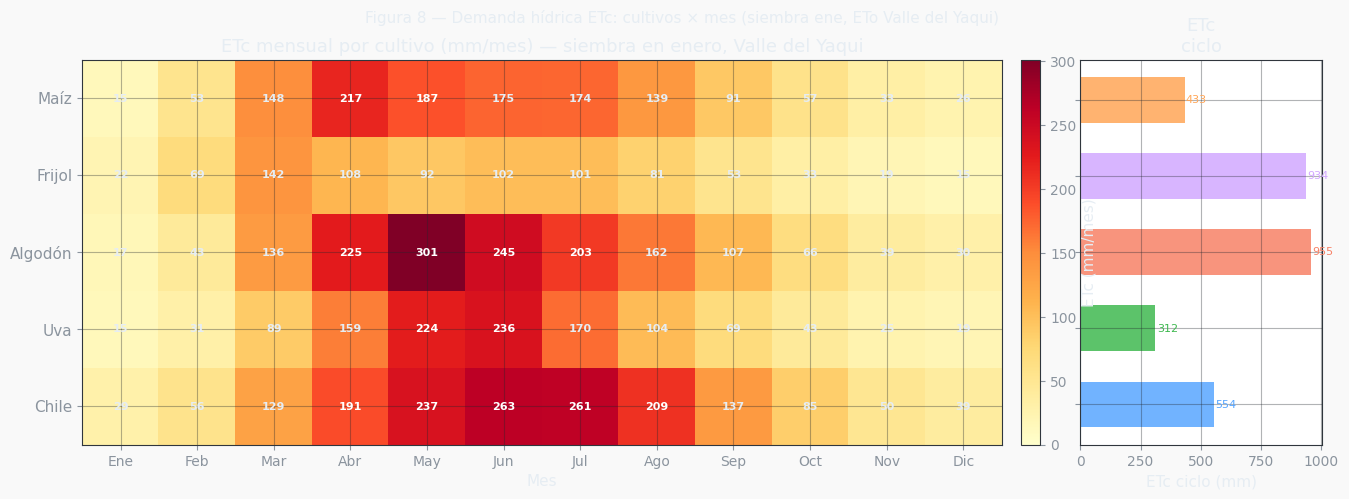


ETc total de ciclo por cultivo:
  Maíz      :    554 mm  (140d) → ~5536 m³/ha
  Frijol    :    312 mm  (110d) → ~3118 m³/ha
  Algodón   :    955 mm  (180d) → ~9553 m³/ha
  Uva       :    934 mm  (215d) → ~9344 m³/ha
  Chile     :    433 mm  (125d) → ~4328 m³/ha


In [18]:
import calendar

# ETo mensual promedio (ya calculado sobre el año)
eto_mensual = {}
for m in range(1, 13):
    mask_m = np.array([
        (pd.Timestamp(2024, 1, 1) + pd.Timedelta(days=int(d)-1)).month == m
        for d in dias
    ])
    eto_mensual[m] = eto_pm[mask_m].mean()

# ETc mensual para cada cultivo (siembra en enero = día 1)
heatmap_data = np.zeros((len(cultivos), 12))

for ci, cultivo in enumerate(cultivos):
    info  = KC_TABLE[cultivo]
    ciclo = sum(info["duracion_etapas"])
    # Para cada mes, calcular ETc diaria media = ETo_mes * Kc(dia_mes)
    dia_acum = 0
    for m in range(1, 13):
        n_dias_mes = calendar.monthrange(2024, m)[1]
        kc_mes = [obtener_kc(cultivo, dia_acum + d) for d in range(1, n_dias_mes + 1)]
        heatmap_data[ci, m-1] = eto_mensual[m] * np.mean(kc_mes) * n_dias_mes  # mm/mes
        dia_acum += n_dias_mes

# --- Heatmap principal ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"wspace": 0.05, "width_ratios": [4, 1]})

ax_hm = axes[0]
im = ax_hm.imshow(heatmap_data, cmap="YlOrRd", aspect="auto", vmin=0)
ax_hm.set_xticks(range(12)); ax_hm.set_xticklabels(meses_labels)
ax_hm.set_yticks(range(len(cultivos)))
ax_hm.set_yticklabels([nombres_display[c] for c in cultivos], fontsize=11)
ax_hm.set_title("ETc mensual por cultivo (mm/mes) — siembra en enero, Valle del Yaqui")
ax_hm.set_xlabel("Mes")
cbar = plt.colorbar(im, ax=ax_hm, fraction=0.03, pad=0.02)
cbar.set_label("ETc (mm/mes)")

# Anotar valores en celdas
for ci in range(len(cultivos)):
    for m in range(12):
        val = heatmap_data[ci, m]
        color_txt = "white" if val > heatmap_data.max() * 0.6 else "#e6edf3"
        ax_hm.text(m, ci, f"{val:.0f}", ha="center", va="center",
                   fontsize=8, color=color_txt, fontweight="bold")

# --- Panel derecho: ETc total del ciclo por cultivo ---
ax_bar = axes[1]
etcs_ciclo = heatmap_data.sum(axis=1)  # mm/ciclo (solo meses con ciclo activo)
# Mejor: calcular ETc total real del ciclo
etcs_ciclo_real = []
for ci, cultivo in enumerate(cultivos):
    info = KC_TABLE[cultivo]
    ciclo = sum(info["duracion_etapas"])
    etc_total = sum(
        eto_pm[d-1] * obtener_kc(cultivo, d)
        for d in range(1, min(ciclo, 365) + 1)
    )
    etcs_ciclo_real.append(etc_total)

bars = ax_bar.barh(range(len(cultivos)), etcs_ciclo_real,
                   color=[PALETTE[i] for i in range(len(cultivos))], alpha=0.85, height=0.6)
ax_bar.set_yticks(range(len(cultivos)))
ax_bar.set_yticklabels([])  # ya mostradas en heatmap
ax_bar.set_xlabel("ETc ciclo (mm)")
ax_bar.set_title("ETc\nciclo")
ax_bar.grid(True, axis="x")
for i, (bar, val) in enumerate(zip(bars, etcs_ciclo_real)):
    ax_bar.text(val + 5, i, f"{val:.0f}", va="center", fontsize=8, color=PALETTE[i])

plt.suptitle("Figura 8 — Demanda hídrica ETc: cultivos × mes (siembra ene, ETo Valle del Yaqui)", fontsize=11)
plt.savefig("fig8_heatmap_etc.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\nETc total de ciclo por cultivo:")
for c, val in zip(cultivos, etcs_ciclo_real):
    ciclo = sum(KC_TABLE[c]["duracion_etapas"])
    print(f"  {nombres_display[c]:<10}: {val:>6.0f} mm  ({ciclo}d) → ~{val*10:.0f} m³/ha")

---
## Resumen de figuras generadas

| Fig | Título | Función principal |
|-----|--------|-------------------|
| 1 | ETo ciclo anual y clima de entrada | `calcular_eto_penman_monteith` + `calcular_eto_hargreaves` |
| 2 | Concordancia PM vs Hargreaves (scatter + error + boxplot mensual) | Comparación de métodos |
| 3 | Sensibilidad de ETo a cada variable climática | `calcular_eto_penman_monteith` — análisis paramétrico |
| 4 | Curvas Kc FAO-56 — 5 cultivos DR-041 | `obtener_kc()` + `KC_TABLE` |
| 5 | Balance hídrico diario simulado 60 días (Maíz) | `calcular_balance_hidrico()` |
| 6 | Propagación de humedad desde el último riego | `propagar_balance_hidrico()` |
| 7 | Costo de bombeo: baseline vs meta MILPÍN + sensibilidad tarifaria | `calcular_costo_riego()` |
| 8 | Mapa de calor ETc mensual × cultivo + ETc total del ciclo | Integración ETo × Kc |

**Supuesto principal compartido:** clima sintético representativo del Valle del Yaqui (27.37°N, 40 m.s.n.m.). Reemplazar con datos reales de `clima_diario` vía NASA POWER para resultados operacionales.